<a href="https://colab.research.google.com/github/alyaavianti1/kkpm/blob/main/MLP_obesity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("obes.csv")

print("Ukuran dataset:", df.shape)
print("\nDistribusi ke-7 Kelas target:")
print(df['NObeyesdad'].value_counts())
df.head()

Saving obes.csv to obes.csv
Ukuran dataset: (2111, 17)

Distribusi ke-7 Kelas target:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
X = df.drop('NObeyesdad', axis=1)
y = df['NObeyesdad']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_encoded = pd.get_dummies(X, drop_first=True)

print("Jumlah kolom fitur sekarang:", X_encoded.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data training:", X_train.shape[0])
print("Data testing:", X_test.shape[0])

Jumlah kolom fitur sekarang: 23
Data training: 1688
Data testing: 423


In [4]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation = 'relu',
    max_iter=500,
    random_state=42
)

mlp.fit(X_train, y_train)
print("Training selesai!")

Training selesai!


In [5]:
y_pred = mlp.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))


Accuracy: 92.91%

Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.96      0.96      0.96        56
      Normal_Weight       0.89      0.81      0.85        62
     Obesity_Type_I       0.97      0.95      0.96        78
    Obesity_Type_II       0.97      0.98      0.97        58
   Obesity_Type_III       1.00      1.00      1.00        63
 Overweight_Level_I       0.81      0.89      0.85        56
Overweight_Level_II       0.88      0.90      0.89        50

           accuracy                           0.93       423
          macro avg       0.93      0.93      0.93       423
       weighted avg       0.93      0.93      0.93       423



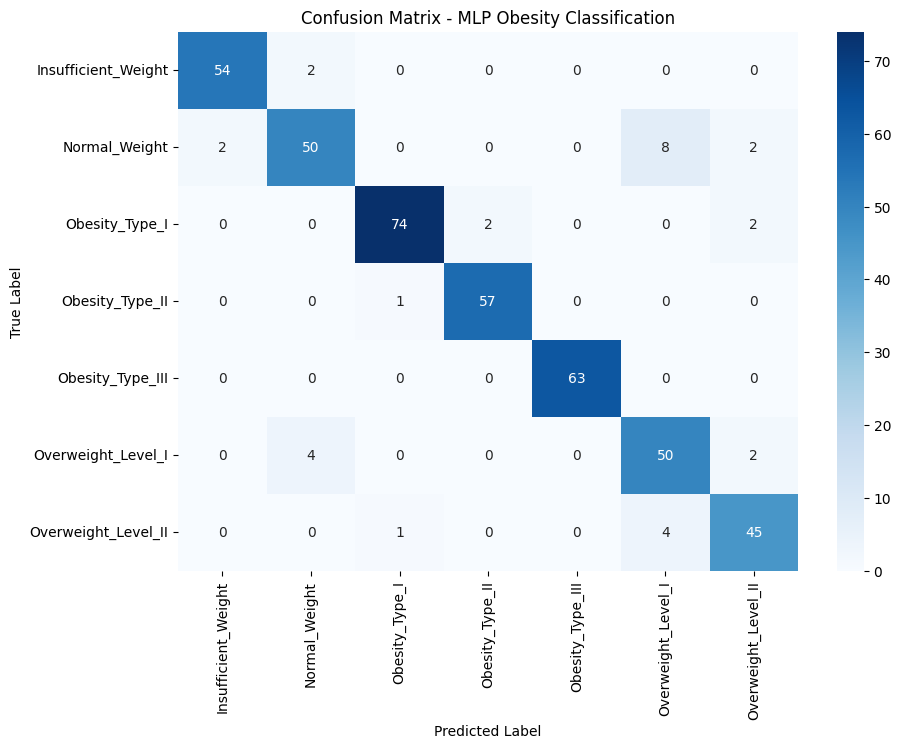

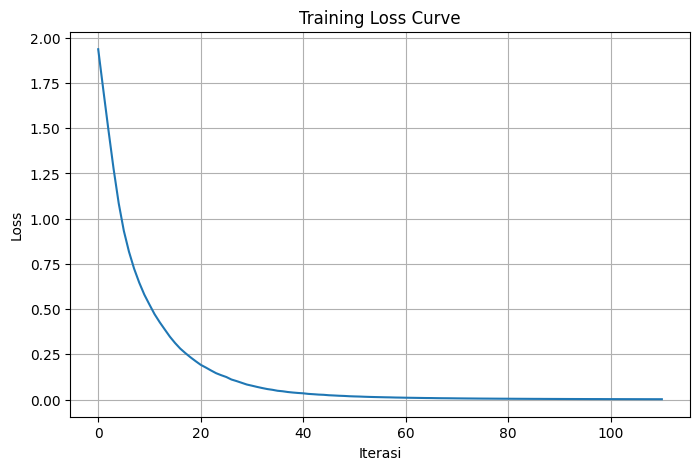

In [6]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(c) for c in le.classes_],
            yticklabels=[str(c) for c in le.classes_])
plt.title("Confusion Matrix - MLP Obesity Classification")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(mlp.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.grid(True)
plt.show()